<a href="https://colab.research.google.com/github/Ammar-creator-cmd/DataVisualization/blob/main/SalaryPrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Data Collection

In [14]:
import pandas as pd
file_id = '1rm-AAkYYVHcpUu4yLP-D1d2D7FETgD-P'
url = 'https://drive.google.com/uc?id={}'.format(file_id)
data = pd.read_csv(url)

### Data Processing


In [15]:
data.head()

,experience,test_score,interview_score,Salary
0,NaN,8.0,8.0,50000
1,NaN,5.0,4.0,22000
2,three,6.0,5.0,30000
3,five,9.0,9.0,55000
4,six,3.0,5.0,13000


In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       15 non-null     object 
 1   test_score       19 non-null     float64
 2   interview_score  19 non-null     float64
 3   Salary           20 non-null     int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 772.0+ bytes


In [17]:
data.describe()

,test_score,interview_score,Salary
count,19.000000,19.000000,20.000000
mean,5.447368,5.657895,30350.000000
std,2.832817,2.516902,19780.439567
min,1.000000,1.000000,500.000000
25%,3.000000,4.500000,12750.000000
50%,5.000000,6.000000,27500.000000
75%,8.000000,7.750000,48500.000000
max,9.000000,9.000000,60000.000000


In [18]:
data.isnull().sum()

,0
experience,5
test_score,1
interview_score,1
Salary,0


In [19]:
data["experience"].value_counts()

,count
experience,
three,2
five,2
six,2
ten,2
one,2
fifteen,1
thirteen,1
four,1
eleven,1


### Data Formatting

In [20]:
# Mapping of experience words to numerical values
ordinal_values = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
                  'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
                  'eleven': 11, 'twelve': 12, 'thirteen': 13, 'fifteen': 15}
# Convert 'experience' column to numerical values using the mapping
data['experience'] = data['experience'].map(ordinal_values)

In [21]:
#Fill missing experience values with the mean experience
mean_experience = data["experience"].mean()
data["experience"] = data["experience"].fillna(mean_experience)

In [22]:
# Fill missing 'test_score' values with the mean experience
data["test_score"] = data ["test_score"].fillna(mean_experience)

In [23]:
# Fill missing 'interview_score' values with the mean experience
data["interview_score"] = data ["interview_score"].fillna(mean_experience)

In [24]:
data.head()

,experience,test_score,interview_score,Salary
0,7.0,8.0,8.0,50000
1,7.0,5.0,4.0,22000
2,3.0,6.0,5.0,30000
3,5.0,9.0,9.0,55000
4,6.0,3.0,5.0,13000


### Visualization Models

> Add blockquote



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

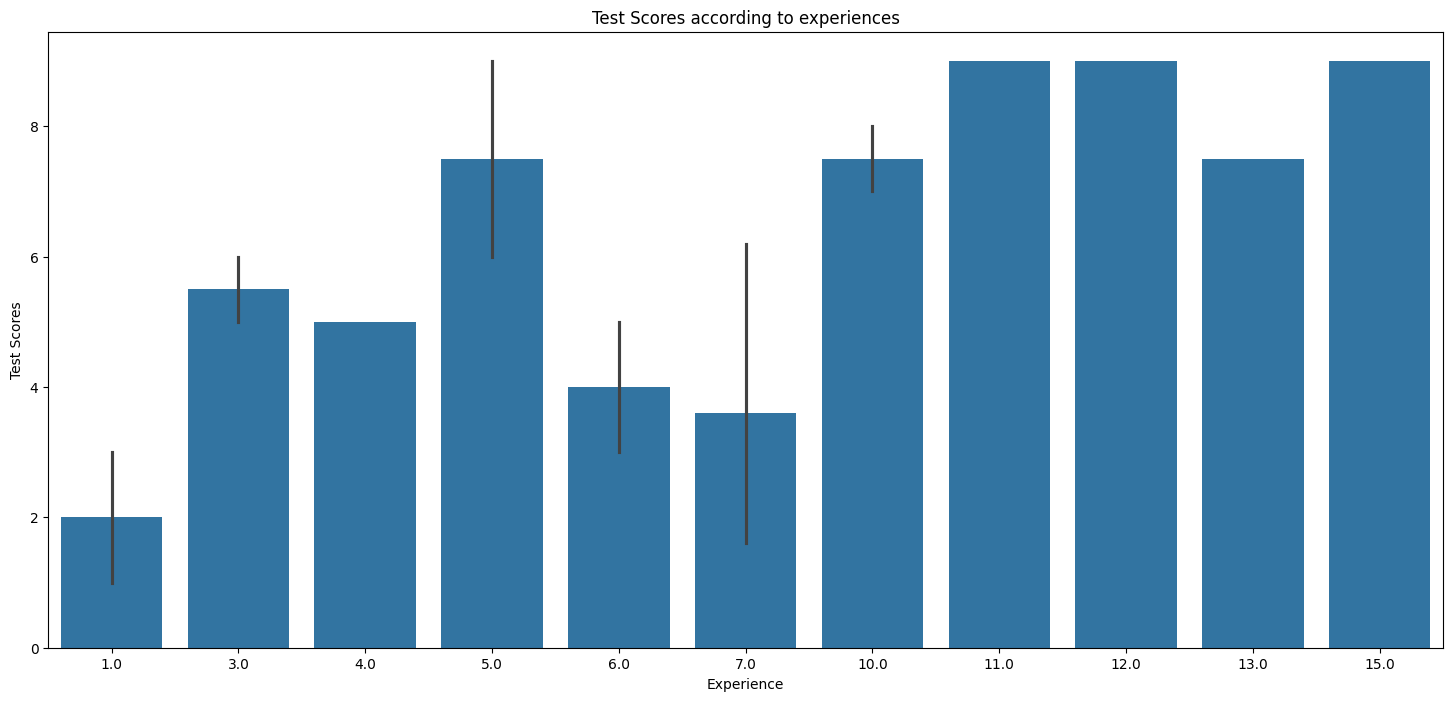

In [26]:
plt.figure(figsize = (18, 8))
sns.barplot(x = data["experience"], y = data["test_score"])
plt.xlabel("Experience")
plt.ylabel("Test Scores")
plt.title("Test Scores according to experiences")
plt.show()

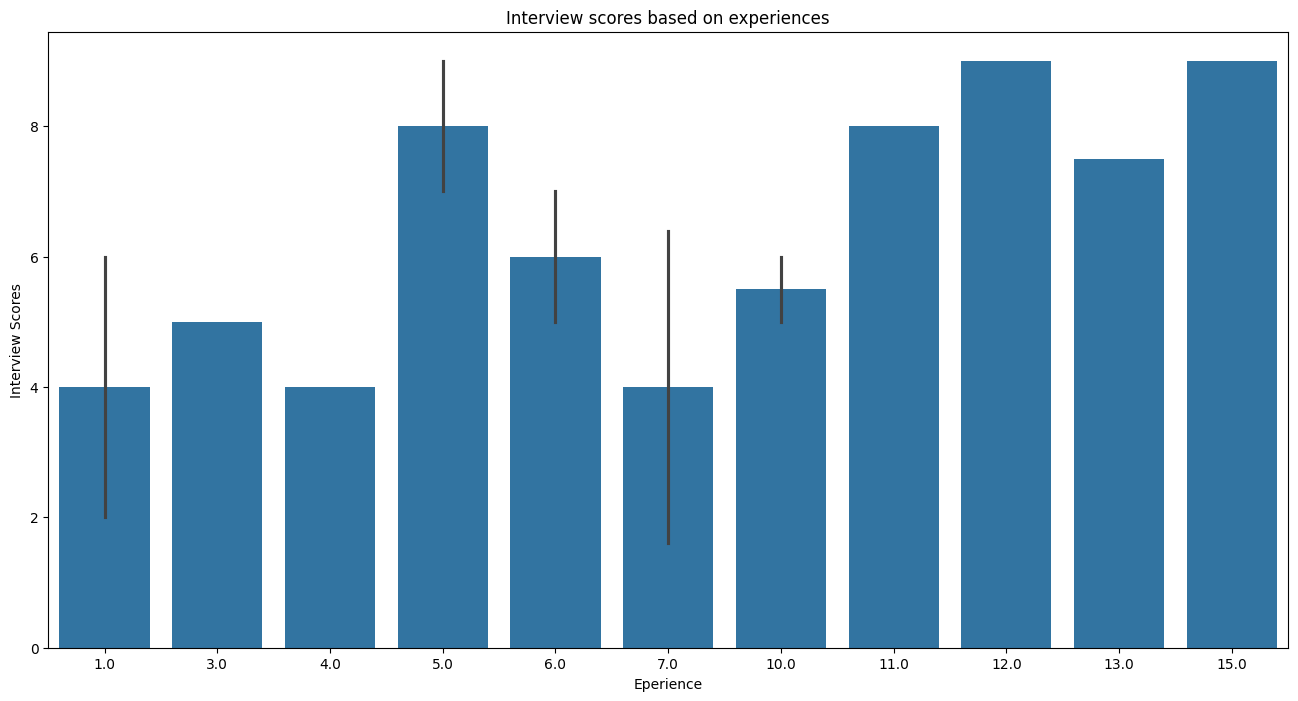

In [27]:
plt.figure(figsize = (16, 8))
sns.barplot(x = data["experience"], y = data["interview_score"])
plt.xlabel("Eperience")
plt.ylabel("Interview Scores")
plt.title("Interview scores based on experiences")
plt.show()

<Figure size 800x800 with 0 Axes>

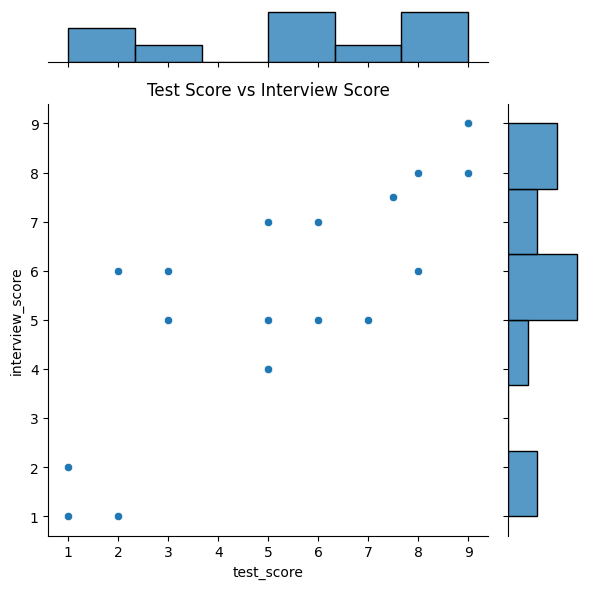

In [28]:
plt.figure(figsize = (8, 8))
sns.jointplot(x = data["test_score"], y = data["interview_score"], kind = "scatter")
plt.title("Test Score vs Interview Score")
plt.tight_layout() # Adjust the layout for complete title
plt.show()

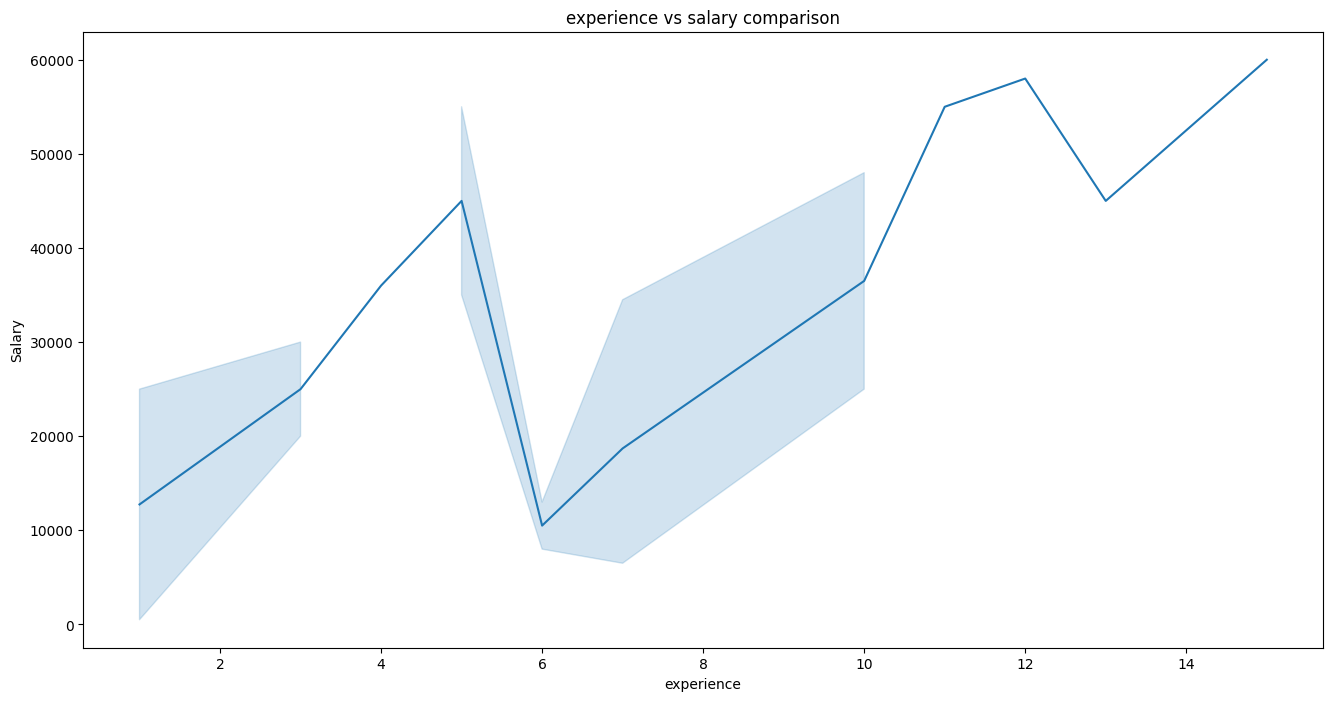

In [29]:
plt.figure(figsize = (16, 8))   #lineplot
sns.lineplot(x = data["experience"], y = data["Salary"])
plt.title("experience vs salary comparison")
plt.show()

<Figure size 1600x800 with 0 Axes>

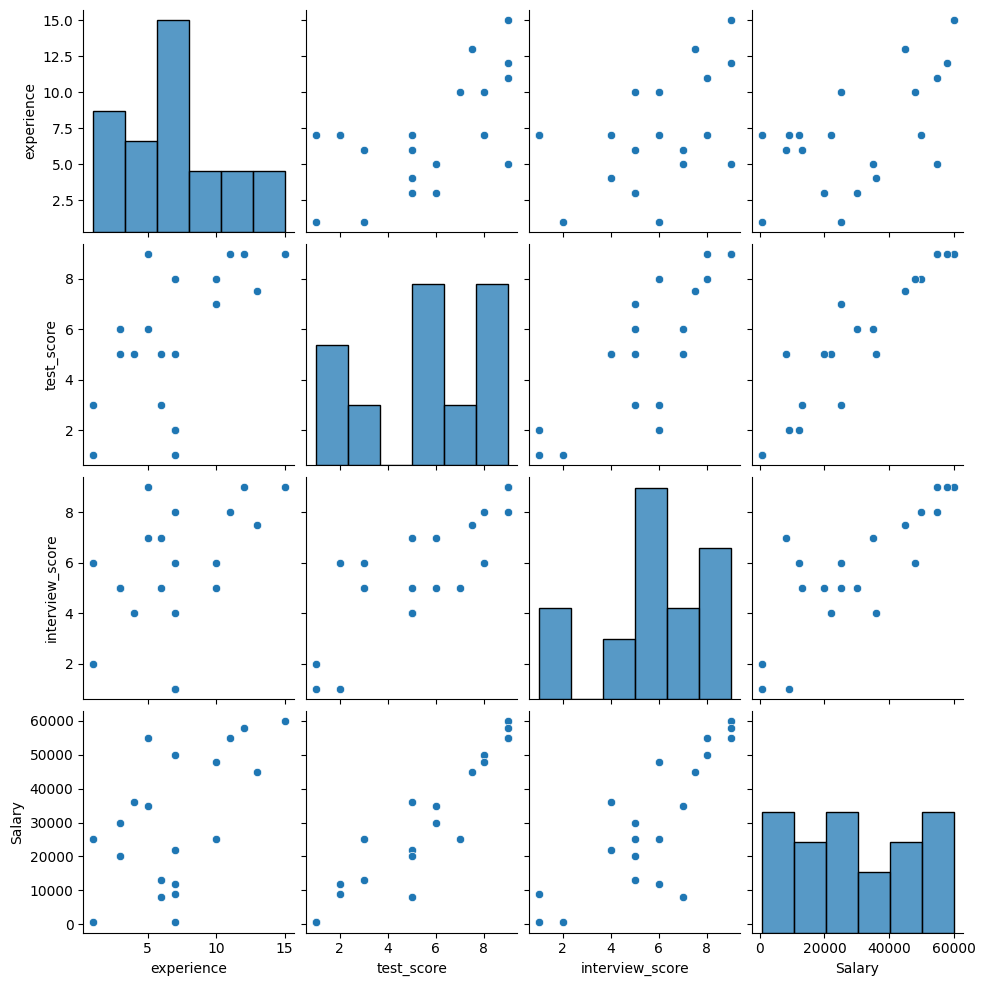

In [30]:
plt.figure(figsize = (16, 8))      #pair plot of everything!
sns.pairplot(data)
plt.show()

### Define Features and Target

In [31]:
# Features are the input variables that help us predict the target
# In this case, 'Experience', 'Test Score', and 'Interview Score' are the features
# Target is what we're trying to predict
# In this case, 'Salary' is the target

In [32]:
features = data.drop(columns = ["Salary"], axis = 1)

In [33]:
target = data["Salary"]

### Data Splitting

In [34]:
from sklearn.model_selection import train_test_split

In [35]:
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

In [36]:
features_train.info()


<class 'pandas.core.frame.DataFrame'>
Index: 16 entries, 8 to 6
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       16 non-null     float64
 1   test_score       16 non-null     float64
 2   interview_score  16 non-null     float64
dtypes: float64(3)
memory usage: 512.0 bytes


In [37]:
features_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4 entries, 0 to 1
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       4 non-null      float64
 1   test_score       4 non-null      float64
 2   interview_score  4 non-null      float64
dtypes: float64(3)
memory usage: 128.0 bytes


### Model Training

In [38]:
from sklearn.linear_model import LinearRegression

In [39]:
#Create a Linear Regression model
linear_model = LinearRegression()

In [40]:
#Train the model using the training data
linear_model.fit(features_train, target_train)

LinearRegression()

### Model Evaluation

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [42]:
#Make predictions using the linear regression model
linear_prediction = linear_model.predict(features_test)

In [43]:
print(linear_prediction)

[46565.31397441  9230.40438671 52809.29937896 25729.73628029]


In [44]:
#Calculate MAE (mean absolute error) for linear regression model's predictions
linear_mae = mean_absolute_error(target_test, linear_prediction)

In [45]:
#Calculate MSE (mean squared error) for linear regression model's predictions
linear_mse = mean_squared_error(target_test, linear_prediction)

In [46]:
#Calculate R2 score for linear regression model's predictions
linear_r2 = r2_score(target_test, linear_prediction)

In [47]:
#Print the evaluation metrics for linear regression
print("Linear Regression Evaluation Metrics: ")
print("-Mean Absolute Error: ", linear_mae)
print("-Mean Squared Error: ", linear_mse)
print("-R2 Score: ", linear_r2)

Linear Regression Evaluation Metrics: 
-Mean Absolute Error:  3031.1796350506647
-Mean Squared Error:  9544457.471757783
-R2 Score:  0.9711375317429362


### Prediction

In [48]:
#Define the features for predictions
new_experience = 7 # Replace with the desired experience value
new_test_score = 8 # Replace with the desired test score value
new_interview_score = 8 # Replace with the desired interview score value

In [49]:
#Create a dictionary with the new data
new_data = {"experience"  : new_experience,
            "test_score" : new_test_score,
            "interview_score": new_interview_score}

In [50]:
#Create a DataFrame from the dictionary
new_data_df = pd.DataFrame([new_data])

#Use the trained linear regression model to make predictions
predicted_salary = linear_model.predict(new_data_df)

In [51]:
print("Predicted Salary: $", round(predicted_salary[0]))

Predicted Salary: $ 46565


### Assignment 2

In [52]:
from sklearn.ensemble import RandomForestRegressor

In [53]:
forrest_model = RandomForestRegressor()

In [54]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- Data Collection (copied from oxFVITnMmmpJ) ---
file_id = '1rm-AAkYYVHcpUu4yLP-D1d2D7FETgD-P'
url = 'https://drive.google.com/uc?id={}'.format(file_id)
data = pd.read_csv(url)

# --- Data Formatting (copied from bLlVk4Dyn5dd, MxELud6ooNDq, kBaLnjSLpLC0, U-EYjW2Bp8JG) ---
# Mapping of experience words to numerical values
ordinal_values = {'one': 1, 'two': 2, 'three': 3, 'four': 4, 'five': 5,
                  'six': 6, 'seven': 7, 'eight': 8, 'nine': 9, 'ten': 10,
                  'eleven': 11, 'twelve': 12, 'thirteen': 13, 'fifteen': 15}
# Convert 'experience' column to numerical values using the mapping
data['experience'] = data['experience'].map(ordinal_values)
#Fill missing experience values with the mean experience
mean_experience = data["experience"].mean()
data["experience"] = data["experience"].fillna(mean_experience)
# Fill missing 'test_score' values with the mean experience
data["test_score"] = data ["test_score"].fillna(mean_experience)
# Fill missing 'interview_score' values with the mean experience
data["interview_score"] = data ["interview_score"].fillna(mean_experience)

# Define features and target
features = data.drop(columns = ["Salary"], axis = 1)
target = data["Salary"]

# Split the data into training and testing sets
features_train, features_test, target_train, target_test = train_test_split(features, target, test_size = 0.2, random_state = 42)

#Train the Random Forest Regressor model
forrest_model.fit(features_train, target_train)

RandomForestRegressor()

In [55]:
#Make predictions using the linear regression model
forrest_prediction = forrest_model.predict(features_test)

In [56]:
print(forrest_prediction)

[45190. 10560. 53390. 19415.]


In [57]:
print(linear_prediction)

[46565.31397441  9230.40438671 52809.29937896 25729.73628029]


In [58]:
import matplotlib.pyplot as plt

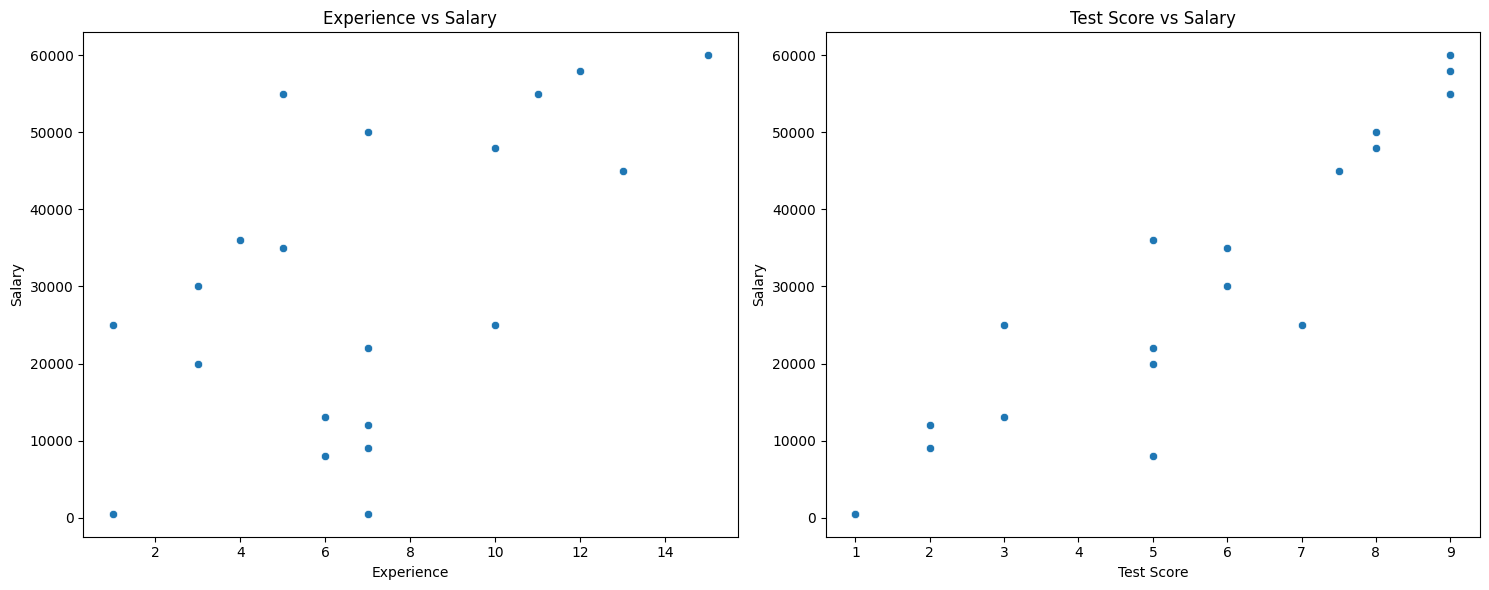

In [59]:
plt.figure(figsize = (10, 10))
plt.bar